# Hola! 😀

Soy **Jaime Paz** y mis amigos me suelen llamar James! – *"Tranquilo, no juego en el Real Madrid"* ⚽😅. Sí, como el futbolista James Rodríguez, pero en versión científico de datos… y mejor no me digas como a él. 😉

Como tu revisor en TripleTen, estoy aquí para ayudarte a pulir tu código y tu forma de trabajar con datos. Si algo necesita un ajuste, no te preocupes: la idea es que cada comentario te acerque más a cómo se trabaja en un entorno profesional y que tu proyecto brille con todo su potencial.

Cada vez que encuentre un detalle importante en tu notebook, te lo señalaré para que puedas corregirlo y seguir creciendo. Si en algún punto no logras resolver algo, también estoy para guiarte en próximos intentos de revisión. 🔁

Es muy importante que, cuando veas mis comentarios en el notebook, **no los muevas, no los modifiques y no los borres**. Así mantenemos un historial claro de lo que ya revisamos y de tus avances. ✅

---

### Formato de Comentarios

Revisaré cuidadosamente tu notebook para asegurar que cumpla con los requisitos y te daré comentarios usando el siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - ¡Excelente trabajo! Esta parte está bien implementada y contribuye de forma positiva al análisis o al proyecto. Sigue aplicando estas buenas prácticas en las siguientes secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Esta parte del código funciona, pero se puede mejorar u optimizar. Tal vez sea más claro, más eficiente o más fácil de mantener. Te señalaré ideas para que puedas reforzar esta sección.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error que es necesario corregir para aprobar esta parte. Revisa el comentario con calma, ajústalo y vuelve a intentarlo; es clave para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto. 💪
- **Áreas de mejora:** Sugerencias claras sobre lo que puedes reforzar. 💡
- **Temas adicionales para investigar:** Ideas opcionales que puedes explorar por tu cuenta para seguir creciendo.

Estos temas adicionales no son obligatorios ahora, pero pueden ayudarte a profundizar en el futuro. 📚

---

Si tienes dudas o quieres responder a un comentario específico, puedes usar este formato:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>Éxito</b> ✅ - ¡Excelente trabajo! Tu proyecto es excepcional y has logrado cubrir los objetivos del mismo. Abajo he dejado mis comentarios y unas pequeñas recomendaciones para que tomes en cuenta en un futuro y te hagan ¡un máster en Data!

¡Felicidades!    

</div>



## Carga y preparación de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
# Cargamos dataset
df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

In [3]:
# Exploramos datos 
df.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [4]:
# Exploramos datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [5]:
# Exploramos datos
df.describe()

,DeviceIDHash,EventTimestamp,ExpId
count,2.441260e+05,2.441260e+05,244126.000000
mean,4.627568e+18,1.564914e+09,247.022296
std,2.642425e+18,1.771343e+05,0.824434
min,6.888747e+15,1.564030e+09,246.000000
25%,2.372212e+18,1.564757e+09,246.000000
50%,4.623192e+18,1.564919e+09,247.000000
75%,6.932517e+18,1.565075e+09,248.000000
max,9.222603e+18,1.565213e+09,248.000000


In [6]:
# Cambiamos nombres de las comlumnas
df.columns = ['event_name','user_id','event_time','exp_id']
print(df.columns)

Index(['event_name', 'user_id', 'event_time', 'exp_id'], dtype='object')


In [7]:
# Revisamos valores nulos
df.isna().sum()

event_name    0
user_id       0
event_time    0
exp_id        0
dtype: int64

In [8]:
# Revisamos valores duplicados
df.duplicated().sum()

413

In [9]:
# Eliminamos valores duplicados
df = df.drop_duplicates()

In [10]:
# Cambiamos tipos de datos
df['event_time'] = pd.to_datetime(df['event_time'], unit='s')
print(df['event_time'].head())

0   2019-07-25 04:43:36
1   2019-07-25 11:11:42
2   2019-07-25 11:28:47
3   2019-07-25 11:28:47
4   2019-07-25 11:48:42
Name: event_time, dtype: datetime64[ns]


In [11]:
# Creamos columna de fecha
df['date'] = df['event_time'].dt.date
print(df['date'].head())

0    2019-07-25
1    2019-07-25
2    2019-07-25
3    2019-07-25
4    2019-07-25
Name: date, dtype: object


## Estudiar y comprobar los datos

In [12]:
# ¿Cuántos eventos hay?
total_events = df.shape[0]
total_events

243713

In [13]:
# ¿Cuántos usuarios hay?
total_users = df['user_id'].nunique()
total_users

7551

In [14]:
# Promedio de eventos por usuario
avg_events_per_user = total_events / total_users
avg_events_per_user

32.27559263673685

En promedio cada usiario realiza aproximadamente 32.27 eventos dentro de la aplicación

In [15]:
# Promedio de tiempo de los datos
df['event_time'].min()

Timestamp('2019-07-25 04:43:36')

In [16]:
df['event_time'].max()

Timestamp('2019-08-07 21:15:17')

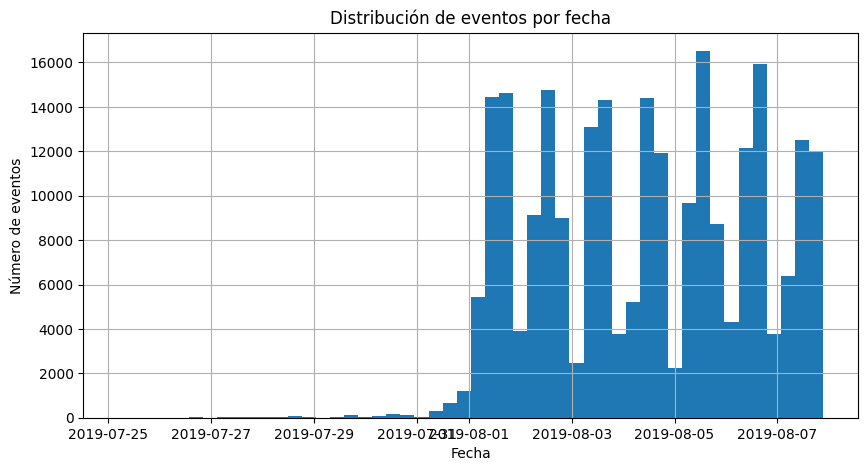

In [17]:
# Historgrama por fecha
plt.figure(figsize=(10,5))

df['event_time'].hist(bins=50)

plt.title("Distribución de eventos por fecha")
plt.xlabel("Fecha")
plt.ylabel("Número de eventos")

plt.show()

In [18]:
# Buscamos cuándo los datos se vuelven completos
# Agrupamos por día
events_by_date = df.groupby('date')['event_name'].count()
events_by_date

date
2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      412
2019-07-31     2030
2019-08-01    36141
2019-08-02    35554
2019-08-03    33282
2019-08-04    32968
2019-08-05    36058
2019-08-06    35788
2019-08-07    31096
Name: event_name, dtype: int64

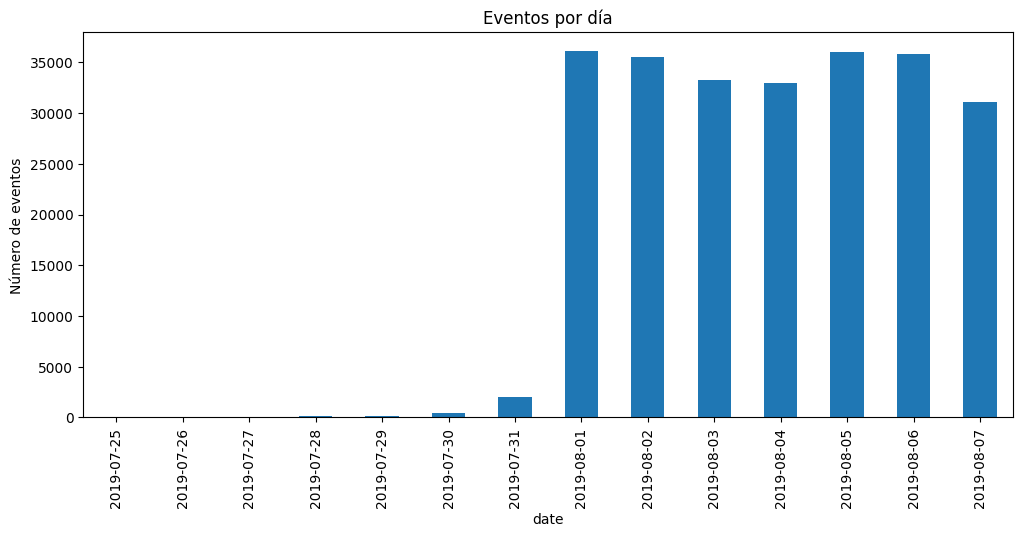

In [19]:
# Visualizamos
events_by_date.plot(kind='bar', figsize=(12,5))

plt.title("Eventos por día")
plt.ylabel("Número de eventos")
plt.show()

Normalmente se observa que los primeros días tienen muy pocos eventos, por lo que se eliminan.

In [20]:
# Filtramos datos completos
df = df[df['event_time'] >= '2019-08-01']
print(df.head())

              event_name              user_id          event_time  exp_id  \
2828            Tutorial  3737462046622621720 2019-08-01 00:07:28     246   
2829    MainScreenAppear  3737462046622621720 2019-08-01 00:08:00     246   
2830    MainScreenAppear  3737462046622621720 2019-08-01 00:08:55     246   
2831  OffersScreenAppear  3737462046622621720 2019-08-01 00:08:58     246   
2832    MainScreenAppear  1433840883824088890 2019-08-01 00:08:59     247   

            date  
2828  2019-08-01  
2829  2019-08-01  
2830  2019-08-01  
2831  2019-08-01  
2832  2019-08-01  


In [21]:
# Revisamos si se perdieron muchos datos
df.shape

(240887, 5)

In [22]:
# Obtenemos valores únicos
df['user_id'].nunique()

7534

In [23]:
# Verificamos grupos experimentales
df['exp_id'].value_counts()

248    84563
246    79302
247    77022
Name: exp_id, dtype: int64

In [68]:
# Comenzamos a armar la visualización del embudo
funnel_events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

# Filtramos dataset
funnel_df = df[df['event_name'].isin(funnel_events)]

# Contamos usuarios únicos por evento
funnel_users = (
    funnel_df.groupby('event_name')['user_id']
    .nunique()
    .reindex(funnel_events)
)

funnel_users

event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Name: user_id, dtype: int64

In [69]:
# Calculamos conversiones entre pasos
conversion_step = funnel_users / funnel_users.shift(1)
conversion_step.iloc[0] = 1

In [70]:
# Conversión total
conversion_total = funnel_users / funnel_users.iloc[0]

In [71]:
# Creamos tabla del embudo
funnel_table = pd.DataFrame({
    'users': funnel_users,
    'step_conversion': conversion_step,
    'total_conversion': conversion_total
})

funnel_table

,users,step_conversion,total_conversion
event_name,,,
MainScreenAppear,7419,1.000000,1.000000
OffersScreenAppear,4593,0.619086,0.619086
CartScreenAppear,3734,0.812976,0.503302
PaymentScreenSuccessful,3539,0.947777,0.477018


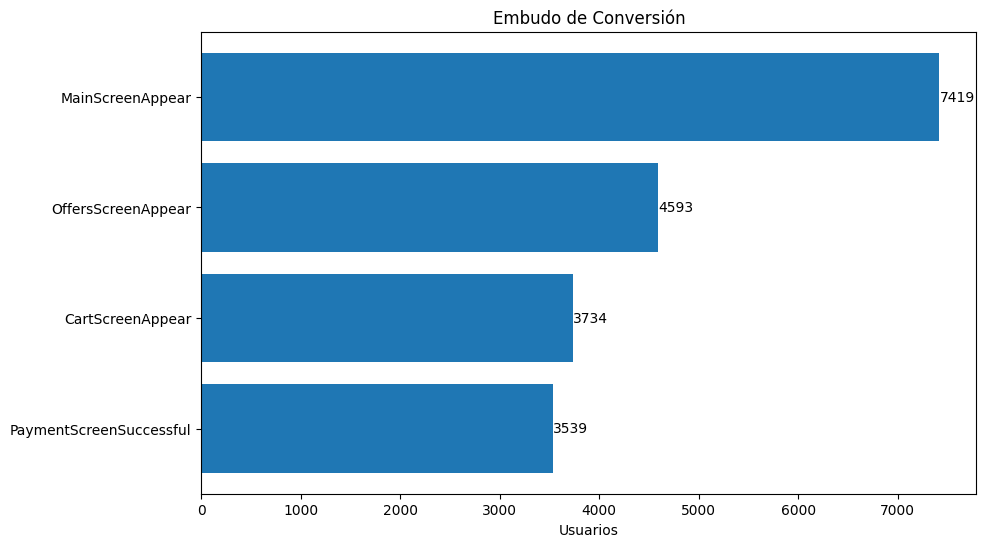

In [73]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    funnel_table.index,
    funnel_table['users']
)

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center')

plt.title('Embudo de Conversión')
plt.xlabel('Usuarios')
plt.gca().invert_yaxis()

plt.show()

## Estudiamos el embudo de eventos

In [24]:
# Eventos y frecuencia
df['event_name'].value_counts()

MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64

In [25]:
# Obtenemos los usuarios por evento
users_per_event = df.groupby('event_name')['user_id'].nunique().sort_values(ascending=False)

users_per_event

event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: user_id, dtype: int64

In [26]:
# Obtenemos la proporción de usuarrios
users_per_event / total_users

event_name
MainScreenAppear           0.982519
OffersScreenAppear         0.608264
CartScreenAppear           0.494504
PaymentScreenSuccessful    0.468680
Tutorial                   0.111244
Name: user_id, dtype: float64

In [27]:
# Contruimos el embudo
funnel = df.groupby('event_name')['user_id'].nunique().reset_index()

funnel = funnel.sort_values(by='user_id', ascending=False)

funnel

,event_name,user_id
1,MainScreenAppear,7419
2,OffersScreenAppear,4593
0,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


In [28]:
# Realizamos conversión entre etapas
main = users_per_event['MainScreenAppear']
offers = users_per_event['OffersScreenAppear']
cart = users_per_event['CartScreenAppear']
payment = users_per_event['PaymentScreenSuccessful']

In [29]:
# Conversiones
offers/main

0.6190861302062273

In [30]:
# Conversiones
cart/offers

0.8129762682342695

In [31]:
# Conversiones
payment/cart

0.9477771826459561

Al parecer la etapa de offers / main es la que presenta mayor fuga de usuarios

In [32]:
# Conversión total
payment/main

0.47701846610055265

Al parecer el 0.47% de usuarios que abren la aplicación completan el proceso de pago.

## Estudio de los resultados del experimento

In [33]:
# Visualizamos usuarios por grupo
df.groupby('exp_id')['user_id'].nunique()

exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

In [34]:
# Evento más popular
df['event_name'].value_counts()

MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64

In [35]:
# Usuarios que hicieron ese evento por pago
event = 'MainScreenAppear'

group_event = df[df['event_name'] == event].groupby('exp_id')['user_id'].nunique()

group_total = df.groupby('exp_id')['user_id'].nunique()

group_event

exp_id
246    2450
247    2476
248    2493
Name: user_id, dtype: int64

In [36]:
# Sacamos proporciones
p1 = group_event[246] / group_total[246]
p1

0.9863123993558777

In [37]:
p2 = group_event[247] / group_total[247]
p2

0.9852765618782332

In [38]:
# Ejecutamos prueba estadística z test
from statsmodels.stats.proportion import proportions_ztest

count = np.array([group_event[246], group_event[247]])
nobs = np.array([group_total[246], group_total[247]])

stat, pval = proportions_ztest(count, nobs)

pval

0.7570597232046099

In [39]:
# Se realiza una función para hacer las pruebas
from statsmodels.stats.proportion import proportions_ztest

def z_test(event, group1, group2):

    event_users = df[df['event_name'] == event].groupby('exp_id')['user_id'].nunique()

    count = np.array([event_users[group1], event_users[group2]])
    nobs = np.array([group_total[group1], group_total[group2]])

    stat, pval = proportions_ztest(count, nobs)

    return pval

Dado que el valor p es mayor a 0.05 no hay diferencia

In [40]:
# Lista de eventos
events = df['event_name'].unique()
events

array(['Tutorial', 'MainScreenAppear', 'OffersScreenAppear',
       'CartScreenAppear', 'PaymentScreenSuccessful'], dtype=object)

In [41]:
# Prueba A/A (246 vs 247)
# Validamos que los controles sean iguales
for event in events:
    
    pval = z_test(event, 246, 247)

    print(event, "p-value:", pval)

Tutorial p-value: 0.9376996189257114
MainScreenAppear p-value: 0.7570597232046099
OffersScreenAppear p-value: 0.2480954578522181
CartScreenAppear p-value: 0.22883372237997213
PaymentScreenSuccessful p-value: 0.11456679313141847


El resultado muestra que todos los valores p son mayores a 0.05. Por lo que se encuentran bien divididos.

In [42]:
# Prueba A/B (246 vs 248)
for event in events:

    pval = z_test(event, 246, 248)

    print(event, "p-value:", pval)

Tutorial p-value: 0.8264294010087645
MainScreenAppear p-value: 0.2949721933554553
OffersScreenAppear p-value: 0.20836205402738917
CartScreenAppear p-value: 0.07842923237520125
PaymentScreenSuccessful p-value: 0.21225532756977972


In [43]:
# Prueba A/B (247 vs 248)
for event in events:

    pval = z_test(event, 247, 248)

    print(event, "p-value:", pval)

Tutorial p-value: 0.7653239224745011
MainScreenAppear p-value: 0.45870536166215137
OffersScreenAppear p-value: 0.919781783059226
CartScreenAppear p-value: 0.5786197879539782
PaymentScreenSuccessful p-value: 0.7373415053803964


In [44]:
# Prueba combinada (246 + 247 vs 248)
# Primero creamos nuevo dataset
df_combined = df.copy()

df_combined['exp_id'] = df_combined['exp_id'].replace({247:246})
print(df_combined['exp_id'].head())

2828    246
2829    246
2830    246
2831    246
2832    246
Name: exp_id, dtype: int64


Vemos que ahora 246 representa ambos controles

In [45]:
# Recalculamos totales
group_total_combined = df_combined.groupby('exp_id')['user_id'].nunique()
print(group_total_combined)

exp_id
246    4997
248    2537
Name: user_id, dtype: int64


In [46]:
# Función para el dataset combinado
def z_test_combined(event):

    event_users = df_combined[df_combined['event_name']==event].groupby('exp_id')['user_id'].nunique()

    count = np.array([event_users[246], event_users[248]])
    nobs = np.array([group_total_combined[246], group_total_combined[248]])

    stat, pval = proportions_ztest(count, nobs)

    return pval

In [47]:
# Ejecutamos pruebas
for event in events:

    pval = z_test_combined(event)

    print(event, "p-value:", pval)

Tutorial p-value: 0.764862472531507
MainScreenAppear p-value: 0.29424526837179577
OffersScreenAppear p-value: 0.43425549655188245
CartScreenAppear p-value: 0.18175875284404386
PaymentScreenSuccessful p-value: 0.6004294282308703


No se encontraron diferencias estadísticamente significativas entre los grupos de control ni entre los grupos de control y el grupo de prueba.

Esto sugiere que el cambio de fuente en la aplicación no tiene un impacto significativo en el comportamiento de los usuarios.

In [52]:
# Creación de función universal de prueba estadística
def run_z_test(data, event, group1, group2):

    event_users = (
        data[data['event_name'] == event]
        .groupby('exp_id')['user_id']
        .nunique()
    )

    count = np.array([
        event_users.get(group1, 0),
        event_users.get(group2, 0)
    ])

    totals = data.groupby('exp_id')['user_id'].nunique()

    nobs = np.array([
        totals[group1],
        totals[group2]
    ])

    stat, pval = proportions_ztest(count, nobs)

    return pval

In [55]:
# Definimos comparaciones automáticamente
comparisons = [
    (246, 247, 'A/A'),
    (246, 248, 'A/B'),
    (247, 248, 'A/B')
]
print(comparisons)

[(246, 247, 'A/A'), (246, 248, 'A/B'), (247, 248, 'A/B')]


In [56]:
# Ejecutamos todas las pruebas automáticamente
results = []

for event in events:
    for g1, g2, test_type in comparisons:

        pval = run_z_test(df, event, g1, g2)

        results.append({
            'event': event,
            'group_1': g1,
            'group_2': g2,
            'test_type': test_type,
            'p_value': pval
        })

results_df = pd.DataFrame(results)
results_df

,event,group_1,group_2,test_type,p_value
0,Tutorial,246,247,A/A,0.937700
1,Tutorial,246,248,A/B,0.826429
2,Tutorial,247,248,A/B,0.765324
3,MainScreenAppear,246,247,A/A,0.757060
4,MainScreenAppear,246,248,A/B,0.294972
5,MainScreenAppear,247,248,A/B,0.458705
6,OffersScreenAppear,246,247,A/A,0.248095
7,OffersScreenAppear,246,248,A/B,0.208362
8,OffersScreenAppear,247,248,A/B,0.919782
9,CartScreenAppear,246,247,A/A,0.228834


In [59]:
# Aplicamos corrección Bonferroni
# Número de pruebas
n_tests = len(results_df)
n_tests

15

In [60]:
alpha = 0.05

In [61]:
alpha_bonf = alpha / n_tests
alpha_bonf

0.0033333333333333335

In [63]:
# Decisión estadística automática
results_df['significant'] = results_df['p_value'] < alpha_bonf
print(results_df['significant'])

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
Name: significant, dtype: bool


In [64]:
# Tabla final ordenada
results_df.sort_values(['event','group_1'])

,event,group_1,group_2,test_type,p_value,significant
9,CartScreenAppear,246,247,A/A,0.228834,False
10,CartScreenAppear,246,248,A/B,0.078429,False
11,CartScreenAppear,247,248,A/B,0.578620,False
3,MainScreenAppear,246,247,A/A,0.757060,False
4,MainScreenAppear,246,248,A/B,0.294972,False
5,MainScreenAppear,247,248,A/B,0.458705,False
6,OffersScreenAppear,246,247,A/A,0.248095,False
7,OffersScreenAppear,246,248,A/B,0.208362,False
8,OffersScreenAppear,247,248,A/B,0.919782,False
12,PaymentScreenSuccessful,246,247,A/A,0.114567,False


In [65]:
# Resumen del experimento
# Diferencias significativas
results_df['significant'].value_counts()

False    15
Name: significant, dtype: int64

## Conclusión del proyecto

Embudo + Experimento

Durante el análisis se estudiaron los eventos registrados en la aplicación con el objetivo de comprender el comportamiento de los usuarios y evaluar el impacto de un experimento A/A/B.

El análisis del embudo mostró que la mayor pérdida de usuarios ocurre entre las etapas de visualización de ofertas y acceso al carrito. Solo una parte de los usuarios que abren la aplicación completan el proceso de compra.

Posteriormente se analizaron los resultados del experimento A/A/B para determinar si el cambio de fuentes en la aplicación afectaba el comportamiento de los usuarios. Primero se compararon los dos grupos de control y no se encontraron diferencias estadísticamente significativas, lo que indica que la división de usuarios se realizó correctamente.

En total se realizaron 15 pruebas de hipótesis, por lo que se aplicó la corrección de Bonferroni para evitar errores tipo I. El nivel de significancia ajustado fue α = 0.0033.

Al comparar el grupo experimental con los grupos de control tampoco se encontraron diferencias significativas en ninguno de los eventos analizados.

Por lo tanto, se concluye que el cambio de fuentes no afecta significativamente el comportamiento de los usuarios dentro de la aplicación.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Buen trabajo alineando el análisis con el objetivo: el embudo muestra claramente que la mayor fuga ocurre entre MainScreenAppear → OffersScreenAppear, y la conversión total hasta pago es ~47.7% (no 0.47%). Tu estudio experimental está bien resuelto: pruebas A/A y A/B con Z-test y corrección Bonferroni, y la conclusión práctica (no cambiar la fuente por falta de efecto) está justificada. 💡   🚀
</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
Buen trabajo Ricardo! Aquí tienes un checklist claro sobre los ítems del nivel BÁSICO e interpretación de los niveles intermedio/avanzado en tu notebook:  

- BÁSICO: rename a snake_case ✅, fechas a datetime ✅, filtrar periodo incompleto ✅, eliminación de duplicados ✅. Falta comprobar explícitamente si algún usuario aparece en más de un grupo experimental (revisar usuarios asignados a múltiples exp_id). ⚠️  

- INTERMEDIO: visualización del embudo ✅, corrección de alpha aplicada (Bonferroni) ✅, interpretación del A/A ✅, análisis de eventos por usuario y combinación de controles ✅, documentación del periodo filtrado ✅. ✅  

- AVANZADO: funciones reutilizables para pruebas ✅, discusión básica de alpha y corrección ✅; podrías profundizar más en potencia estadística y errores tipo II. 🔁  

Ahora, si quieres comprobar rápido la asignación por usuario usa: df.groupby('user_id')['exp_id'].nunique().sort_values(ascending=False).head() 😉 🚀
</div>

### Conclusiones y recomendaciones
- Nivel general: en conjunto, etu trabajo se sitúa más en un nivel intermedio con elementos avanzados bien implementados (funciones reutilizables y corrección por comparaciones múltiples). ✅🚀  
- Fortalezas principales:  
  - Preprocesamiento claro y correcto (renombrado, conversión de timestamps, filtrado por fecha). ✅  
  - Análisis del embudo bien planteado y visualizado; cálculo y presentación de conversiones paso a paso. 📊  
  - Evaluación experimental adecuada: Z-tests por proporción, A/A check, pruebas A/B y ajuste Bonferroni. 🧪  
- Áreas de oportunidad y mejora:
  - Toma en cuenta que faltó verificar si hay usuarios asignados a más de un grupo (comprobar unicidad de user_id por exp_id). -  **Te recomiendo nunca pasarlo por alto para las siguientes fases....** ⚠️  
  - Revisa la presentación de porcentajes (corregir confusión 0.477 → 47.7%) y añade interpretación de tamaños del efecto (no solo p-values). 💡  
- Vas muy bien 🏅🏅🏅 — el flujo de trabajo está completo y las conclusiones son coherentes con los datos; con las mejoras sugeridas (verificar asignación de usuarios entre grupos y revisar formato de porcentajes ) tu entrega pasará a un nivel aún más profesional. ¡Sigue así! 💪📈